In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/processed/nav_history_clean.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print("Data Loaded Successfully")

Data Loaded Successfully


In [4]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend for All Schemes (2022–2026)"
)

fig.show()

### Observation 1

NAV values generally show an upward trend from 2022 to 2026, indicating long-term growth across most mutual fund schemes. Some schemes exhibit higher volatility than others.


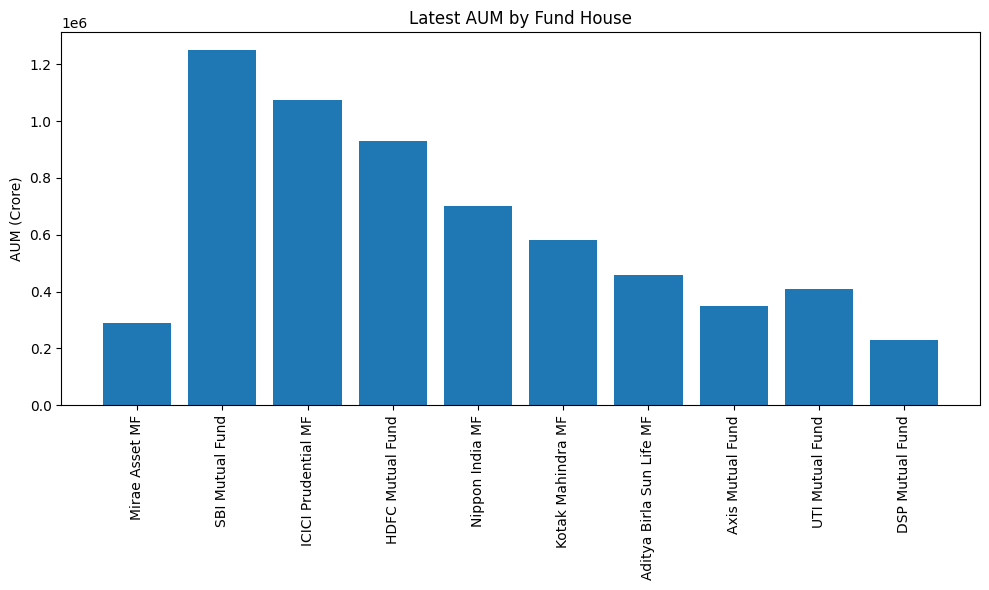

In [6]:
aum_latest = aum.sort_values("date").groupby("fund_house").tail(1)

plt.figure(figsize=(10,6))
plt.bar(aum_latest["fund_house"], aum_latest["aum_crore"])
plt.xticks(rotation=90)
plt.title("Latest AUM by Fund House")
plt.ylabel("AUM (Crore)")
plt.tight_layout()
plt.show()

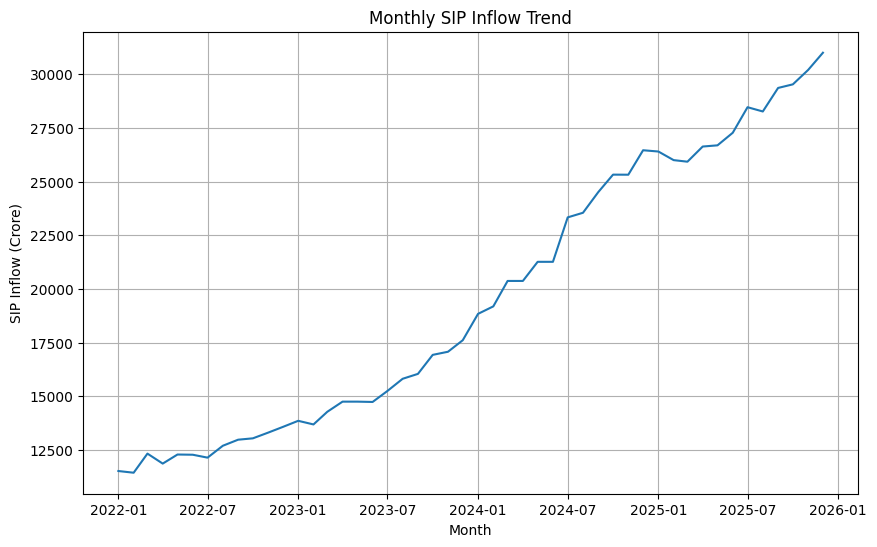

In [7]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(10,6))
plt.plot(sip["month"], sip["sip_inflow_crore"])
plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.show()

### Observation 3

Monthly SIP inflows show a generally increasing trend, indicating growing retail investor participation in mutual funds over time.

In [9]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.head())

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


In [11]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")
print(category.head())

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


In [12]:
print(category.columns)


Index(['month', 'category', 'net_inflow_crore'], dtype='str')


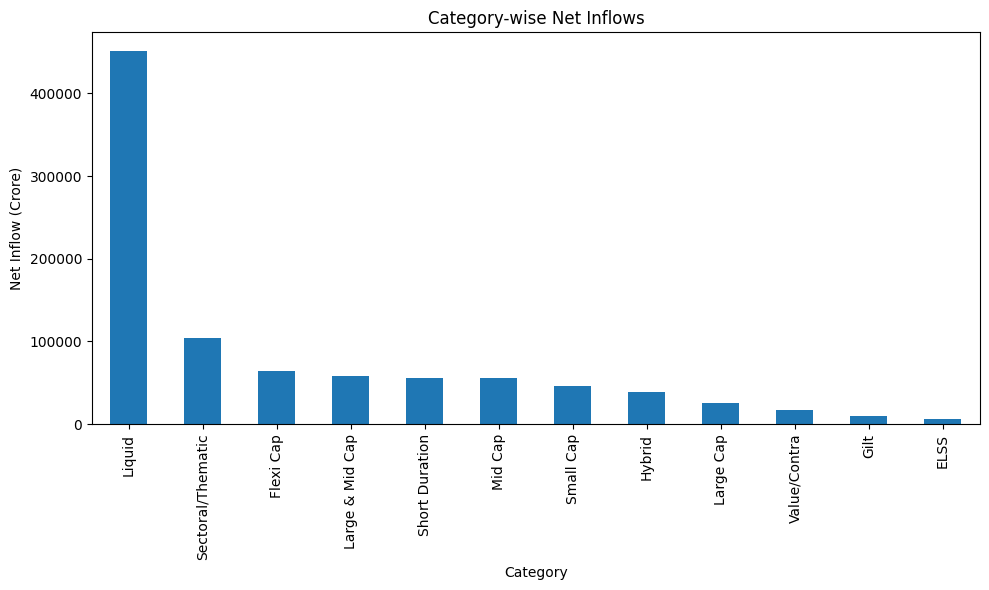

In [13]:
category_group = category.groupby(
    "category"
)["net_inflow_crore"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))
category_group.plot(kind="bar")

plt.title("Category-wise Net Inflows")
plt.ylabel("Net Inflow (Crore)")
plt.xlabel("Category")

plt.tight_layout()
plt.show()

In [14]:
investor = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

print(investor.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


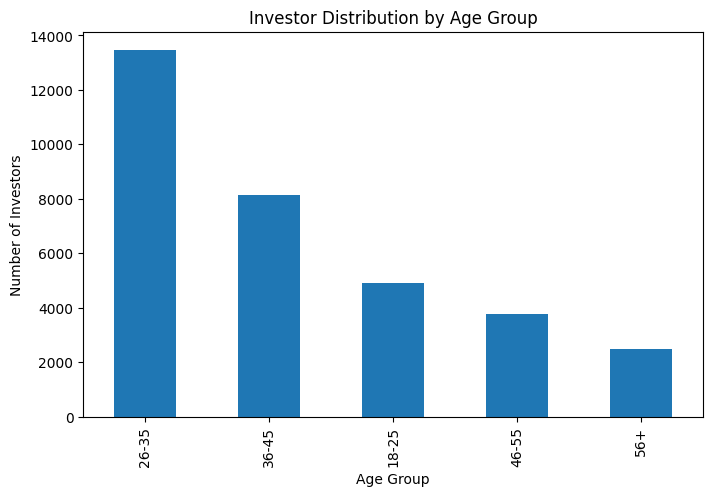

In [15]:
investor["age_group"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Investor Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.show()

### Observation 5

Investor participation varies across age groups, helping identify the dominant customer segments investing in mutual funds.

In [16]:
print(investor["age_group"].value_counts())

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


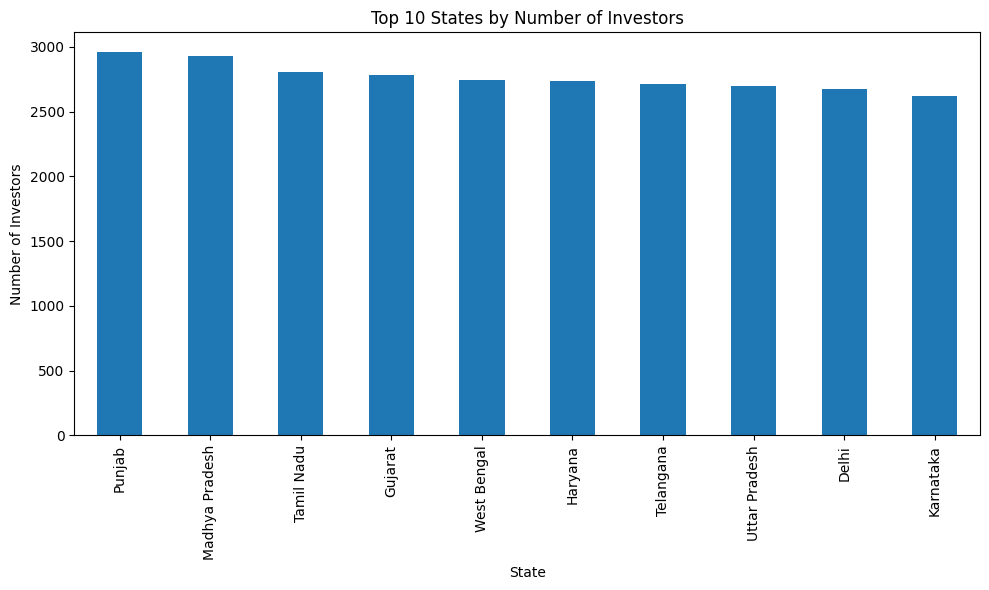

In [41]:
investor["state"].value_counts().head(10).plot(
kind="bar",
figsize=(10,6)
)

plt.title("Top 10 States by Number of Investors")
plt.xlabel("State")
plt.ylabel("Number of Investors")

plt.tight_layout()
plt.show()

### Observation 6

Investor participation is concentrated in a few states, highlighting key geographic markets for mutual fund investments.

In [42]:
print(investor["city_tier"].value_counts())

city_tier
T30    21719
B30    11059
Name: count, dtype: int64


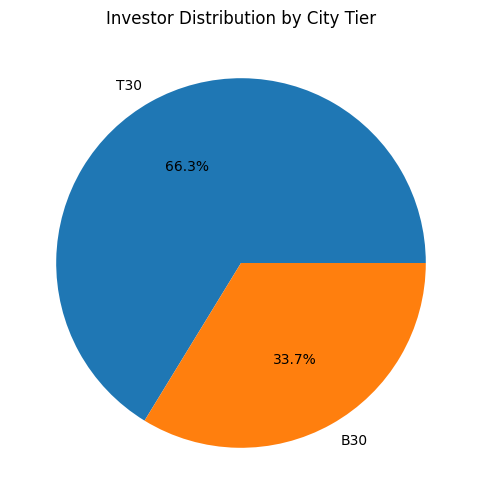

In [43]:
investor["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Investor Distribution by City Tier")
plt.ylabel("")

plt.show()

### Observation 7

A significant share of investors comes from T30 cities, though B30 participation highlights increasing mutual fund penetration beyond major metropolitan areas.

In [44]:
print(investor["gender"].value_counts())

gender
Male      21809
Female    10969
Name: count, dtype: int64


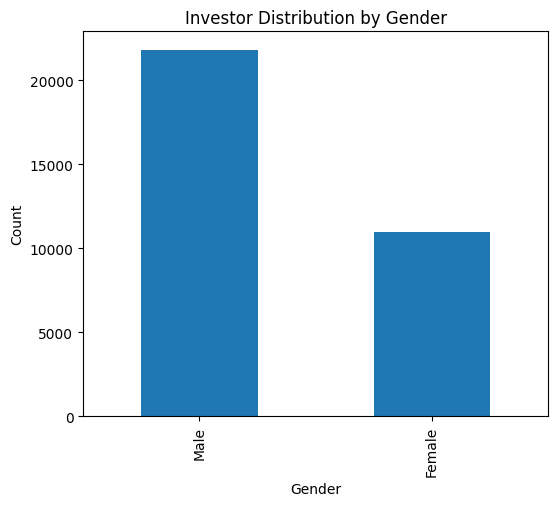

In [45]:
investor["gender"].value_counts().plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Investor Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### Observation 8

Gender-wise investor participation reveals the dominant investor segment and highlights opportunities for broader financial inclusion.

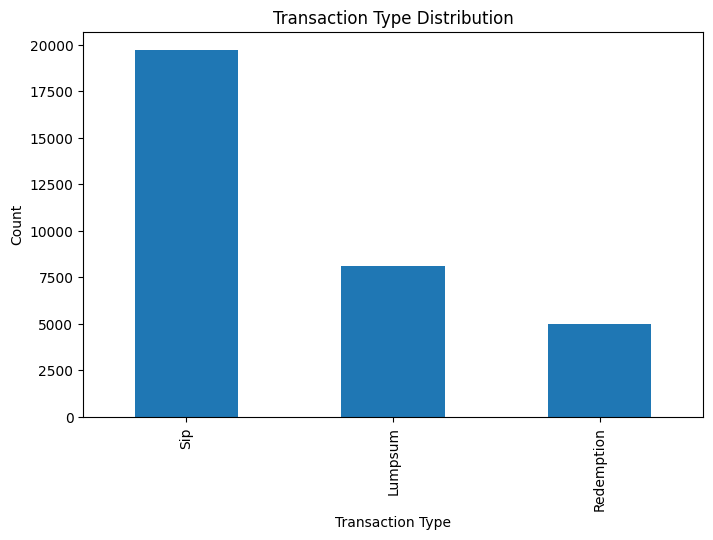

In [48]:
investor["transaction_type"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

### Observation 9

SIP transactions contribute a major share of investor activity, reflecting a preference for systematic investing over lump-sum investments.

In [50]:
investor["annual_income_lakh"]

0        77.1
1         7.1
2        47.2
3        54.4
4        14.5
         ... 
32773    22.5
32774    27.6
32775     8.4
32776    13.0
32777    21.7
Name: annual_income_lakh, Length: 32778, dtype: float64

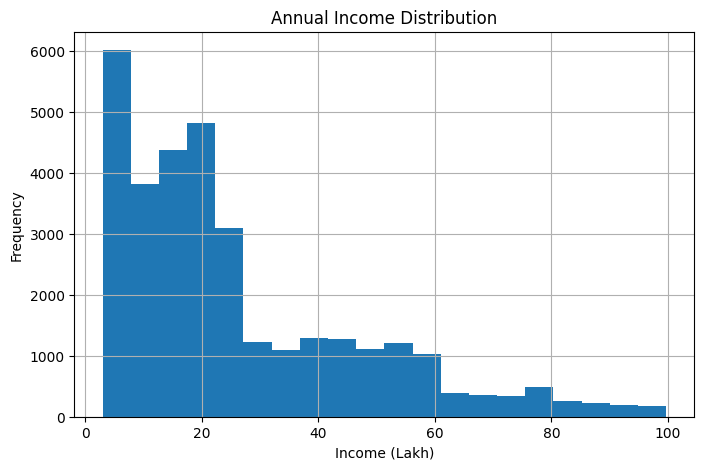

In [52]:
investor["annual_income_lakh"].hist(
    bins=20,
    figsize=(8,5)
)

plt.title("Annual Income Distribution")
plt.xlabel("Income (Lakh)")
plt.ylabel("Frequency")

plt.show()

In [56]:
investor["kyc_status"].value_counts()

kyc_status
Verified    30146
Pending      2632
Name: count, dtype: int64

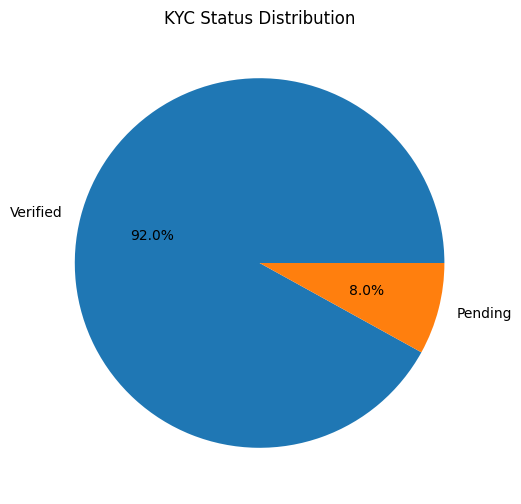

In [57]:
investor["kyc_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("KYC Status Distribution")
plt.ylabel("")
plt.show()

### Observation 11

Approximately 92% of investors have completed KYC verification, while only 8% remain pending. This indicates strong regulatory compliance and investor onboarding across the mutual fund ecosystem.

In [58]:
print(fund_master["fund_house"].value_counts())

fund_house
SBI Mutual Fund             5
HDFC Mutual Fund            5
ICICI Prudential MF         5
Nippon India MF             5
Kotak Mahindra MF           4
Axis Mutual Fund            4
Aditya Birla Sun Life MF    3
UTI Mutual Fund             3
Mirae Asset MF              3
DSP Mutual Fund             3
Name: count, dtype: int64


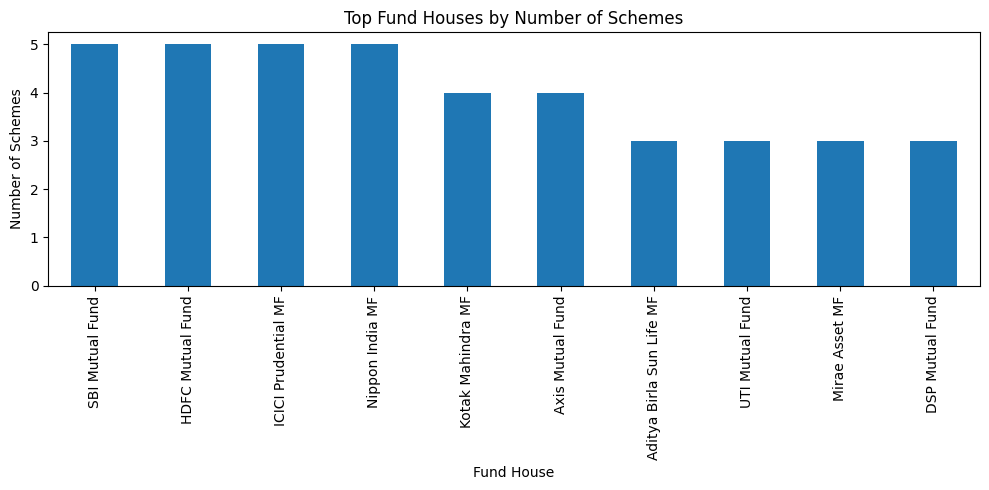

In [59]:
fund_master["fund_house"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Fund Houses by Number of Schemes")
plt.xlabel("Fund House")
plt.ylabel("Number of Schemes")

plt.tight_layout()
plt.show()

### Observation 12

A few fund houses manage a large number of schemes, showing market concentration among leading AMCs.

In [65]:
scheme_perf = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

print(scheme_perf.head())

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

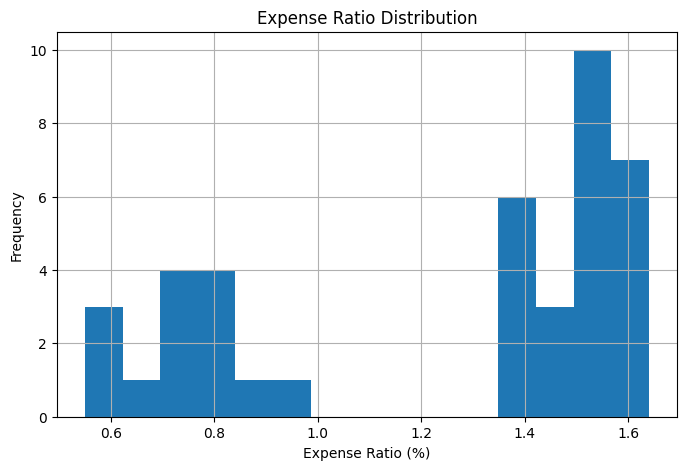

In [66]:
scheme_perf["expense_ratio_pct"].hist(
    bins=15,
    figsize=(8,5)
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Frequency")

plt.show()

### Observation 13

Most schemes have expense ratios between 0.5% and 1.6%, indicating relatively consistent fund management costs across the mutual fund universe.

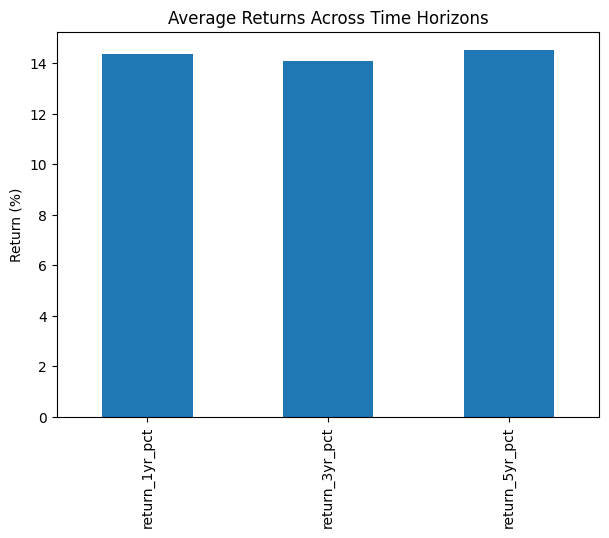

In [67]:
scheme_perf[[
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]].mean().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Returns Across Time Horizons")
plt.ylabel("Return (%)")

plt.show()

### Observation 14

Long-term returns generally outperform short-term returns, highlighting the benefits of long-term investing.

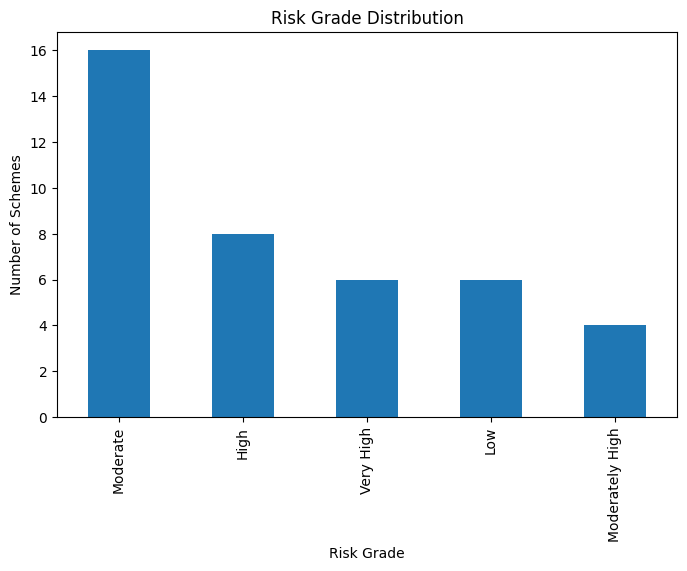

In [70]:
scheme_perf["risk_grade"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Risk Grade Distribution")
plt.xlabel("Risk Grade")
plt.ylabel("Number of Schemes")

plt.show()

### Observation 15

A significant number of schemes fall into Moderate and High risk categories, reflecting the dominance of growth-oriented investment products.